In [113]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [114]:
df = pd.read_csv('Crop_recommendation.csv')

In [115]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [116]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [117]:
df.duplicated().sum()

np.int64(0)

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [119]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [120]:
df.corr

<bound method DataFrame.corr of         N   P   K  temperature   humidity        ph    rainfall   label
0      90  42  43    20.879744  82.002744  6.502985  202.935536    rice
1      85  58  41    21.770462  80.319644  7.038096  226.655537    rice
2      60  55  44    23.004459  82.320763  7.840207  263.964248    rice
3      74  35  40    26.491096  80.158363  6.980401  242.864034    rice
4      78  42  42    20.130175  81.604873  7.628473  262.717340    rice
...   ...  ..  ..          ...        ...       ...         ...     ...
2195  107  34  32    26.774637  66.413269  6.780064  177.774507  coffee
2196   99  15  27    27.417112  56.636362  6.086922  127.924610  coffee
2197  118  33  30    24.131797  67.225123  6.362608  173.322839  coffee
2198  117  32  34    26.272418  52.127394  6.758793  127.175293  coffee
2199  104  18  30    23.603016  60.396475  6.779833  140.937041  coffee

[2200 rows x 8 columns]>

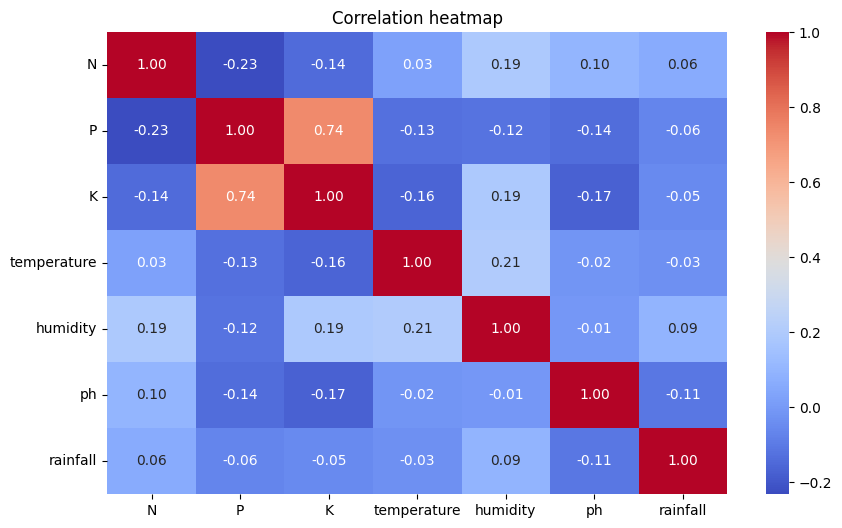

In [121]:
corr = df.drop('label', axis = 1 ).corr()

plt.figure(figsize = (10,6))
sns.heatmap( corr, cmap = 'coolwarm', annot = True, fmt = '.2f' )

plt.title("Correlation heatmap")
plt.show()


In [122]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [123]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

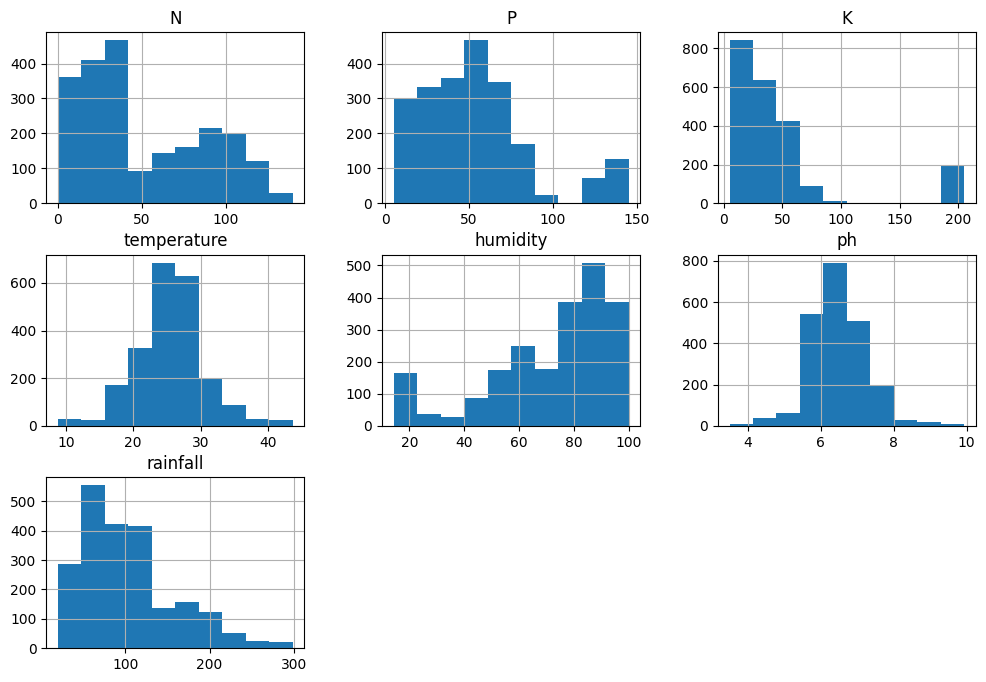

In [124]:
df.hist(figsize = (12,8))

plt.show()

The rainfall feature appears to follow an approximately normal distribution. Most of the other numerical features, such as Nitrogen (N), Phosphorus (P), Potassium (K), temperature, humidity, and pH, exhibit either positive (right) skewness or negative (left) skewness.

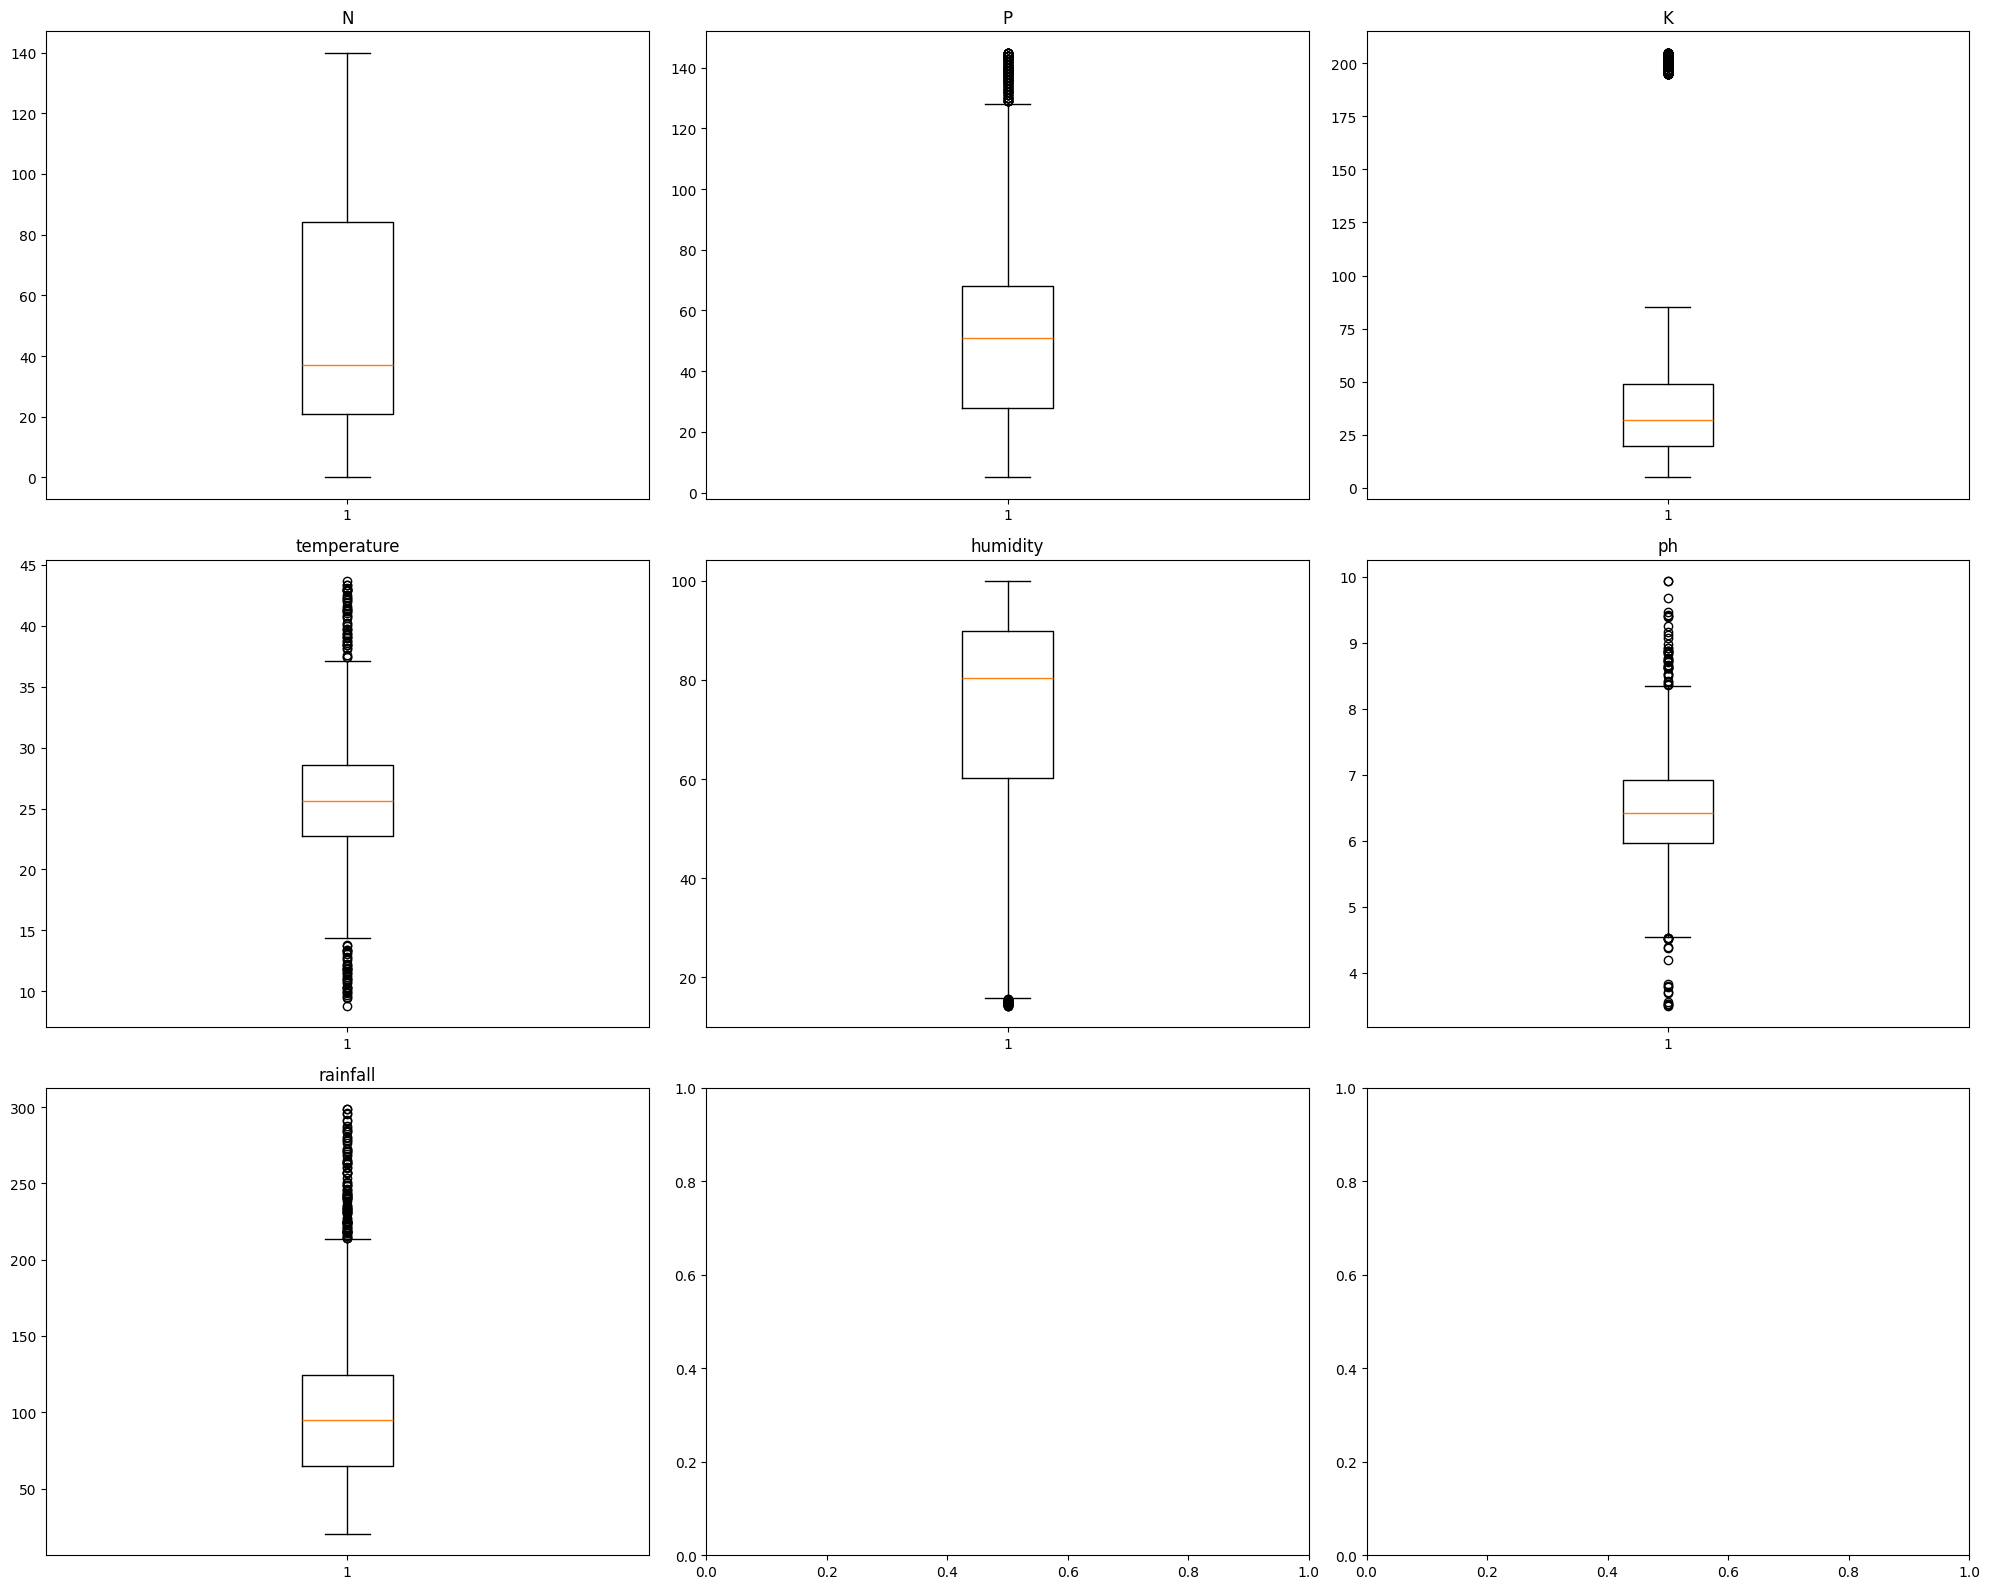

In [125]:
fig, axes = plt.subplots( 3,3, figsize = (20,16))

numerical_columns = df.select_dtypes( include = 'number').columns

for ax, col in zip(axes.flatten(), numerical_columns):
    ax.boxplot(df[col])
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [126]:
# Detecting Outliers Using the IQR Method

Q1 = df['N'].quantile(0.25)
Q3 = df['N'].quantile(0.75)

IQR = Q3-Q1

lower  = Q1 - 1.5*IQR
higher = Q3 + 1.5*IQR

outliers = df[( df['N'] < lower) | (df['N'] >higher)]

outliers

,N,P,K,temperature,humidity,ph,rainfall,label


In [127]:
Q1 = df['P'].quantile(0.25)
Q3 = df['P'].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

outliers = df[(df['P']<lower)|(df['P']>upper)]

outliers
outliers['label'].value_counts()

label
apple     70
grapes    68
Name: count, dtype: int64

Outliers were detected in the Phosphorus (P) feature using the IQR method. Upon investigation, all of these outliers belonged to the apple (70 records) and grapes (68 records) crop classes. This indicates that the high phosphorus values are likely genuine characteristics of these crops rather than data quality issues. Therefore, the outliers were retained.

In [128]:
Q1 = df['K'].quantile(0.25)
Q3 = df['K'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[( df['K'] < lower ) | ( df['K'] > upper ) ]
outliers
outliers['label'].value_counts()

label
grapes    100
apple     100
Name: count, dtype: int64

Using the IQR method, I found outliers in the Potassium (K) feature. After investigating these records, I observed that most of the outliers belonged to the grapes and apple crop classes. This suggests that the high potassium values are characteristic of these crops rather than data entry errors. Therefore, I retained these observations in the dataset.

In [129]:
# Find the pH outliers

Q1 = df['ph'].quantile(0.25)
Q3 = df['ph'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[( df['ph'] < lower ) | ( df['ph'] > upper ) ]
outliers
outliers['label'].value_counts()


label
mothbeans    42
chickpea     13
mango         2
Name: count, dtype: int64

In [130]:
outliers[['ph', 'label']].sort_values(by='ph')

,ph,label
557,3.504752,mothbeans
529,3.510404,mothbeans
582,3.525366,mothbeans
599,3.532009,mothbeans
561,3.558823,mothbeans
500,3.692864,mothbeans
521,3.711059,mothbeans
537,3.793575,mothbeans
526,3.808429,mothbeans
535,3.828031,mothbeans


The IQR method identified outliers in the pH feature. After investigation, these outliers were found to belong mainly to the mothbeans (42), chickpea (13), and mango (2) crop classes. The pH values ranged between 3.5 and 9, which are realistic soil pH values for agricultural conditions. Therefore, these observations were considered genuine and were retained in the dataset

In [131]:
# Find the temperature outliers

Q1 = df['temperature'].quantile(0.25)
Q3 = df['temperature'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[( df['temperature'] < lower ) | ( df['temperature'] > upper ) ]
outliers
outliers['label'].value_counts()

label
papaya    35
grapes    34
orange    17
Name: count, dtype: int64

In [132]:
print(outliers['temperature'].min())
print(outliers['temperature'].max())

8.825674745
43.67549305


The IQR method identified outliers in the temperature feature. After investigation, these outliers were primarily associated with papaya (35 samples), grapes (34 samples), and orange (17 samples). The temperature values ranged from 8.83°C to 43.68°C, which are realistic agricultural conditions. Therefore, these observations were considered genuine and were retained in the dataset.

In [133]:
# Find the pH outliers

Q1 = df['rainfall'].quantile(0.25)
Q3 = df['rainfall'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[( df['rainfall'] < lower ) | ( df['rainfall'] > upper ) ]
outliers
outliers['label'].value_counts()

label
rice       68
papaya     17
coconut    15
Name: count, dtype: int64

In [134]:
print(outliers['rainfall'].min())
print(outliers['rainfall'].max())

213.9011021
298.5601175


The IQR method identified outliers in the rainfall feature. Upon investigation, these outliers were primarily associated with rice (68 samples), papaya (17 samples), and coconut (15 samples). The rainfall values ranged from 213 mm to 298 mm, which are realistic for these water-intensive crops. Therefore, these are statistical outliers relative to the rest of the dataset, but not data errors. Hence, the outliers were retained for model training.

In [135]:
# Feature and Target Separation

x = df.drop('label', axis = 1 )
y = df['label']


In [136]:
x.shape

(2200, 7)

In [137]:
y.shape

(2200,)

In [138]:
# Label encoding of target feature

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [139]:
# Train-Test Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split( x,y,test_size = 0.20, stratify = y,  random_state = 42)

In [140]:
# Training the Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier( random_state = 42 )

dtc.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [141]:
y_pred = dtc.predict(x_test)

In [142]:
# Model Evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9795454545454545

Confusion Matrix:

[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 16  0  0  0  0  0  0  0  2  1  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 18  0  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0 19  0  0  0  

# Hyper parameter tuning

In [143]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier


param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha' : [ 0.0, 0.001, 0.005, 0.1]
}

In [150]:
dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'ccp_alpha': [0.0, 0.001, 0.005, 0.1],
                         'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [151]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)

Best Parameters: {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Cross Validation Score: 0.9857954545454545


In [152]:
best_dt = grid_search.best_estimator_

y_pred1 = best_dt.predict(x_test)

In [147]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))

Test Accuracy: 0.9795454545454545
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.80      0.89        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      0.95      0.95        20
           9       1.00      1.00      1.00        20
          10       0.86      0.90      0.88        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.86      0.95      0.90        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00    

In [153]:
print("Default Accuracy:", accuracy_score(y_test, y_pred))
print("Tuned Accuracy:", accuracy_score(y_test, y_pred1))

Default Accuracy: 0.9795454545454545
Tuned Accuracy: 0.9795454545454545


In [154]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
0.9857954545454545


Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation to optimize the Decision Tree model. Both pre-pruning (max_depth, min_samples_split, min_samples_leaf) and post-pruning (ccp_alpha) parameters were included in the search. The tuned model achieved similar accuracy to the baseline model, indicating that the default Decision Tree already generalized well on this dataset. Nevertheless, hyperparameter tuning confirmed the optimal parameter combination and reduced the likelihood of overfitting. hence, I have choosen tuned model itself for the prediction.

In [165]:
# Finding important features


feature_importance = pd.DataFrame( {
                 'feature': x.columns,
                  'importance': best_dt.feature_importances_
})

# Sort in descending order

feature_importance = feature_importance.sort_values (
                      by = 'importance', ascending = False )

print(feature_importance)

       feature  importance
6     rainfall    0.319636
1            P    0.225141
4     humidity    0.198386
0            N    0.144406
2            K    0.097726
5           ph    0.007416
3  temperature    0.007288


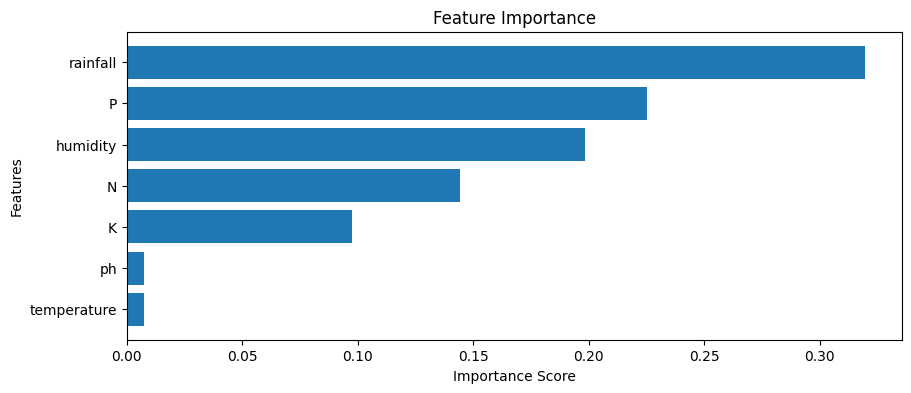

In [166]:
# Plot Feature Importance

plt.figure(figsize = (10,4))

plt.barh( feature_importance['feature'], feature_importance['importance'])

plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

Feature importance analysis revealed that rainfall was the most influential feature in crop prediction, followed by phosphorus (P) and humidity. These features contributed the most to reducing impurity and were used more frequently by the Decision Tree to make splitting decisions. In contrast, pH had the lowest importance, indicating that it contributed relatively less to the model's predictions. This suggests that environmental factors such as rainfall and humidity, along with key soil nutrients, play a major role in determining the most suitable crop.

In [162]:
# Decision Tree Visualization 

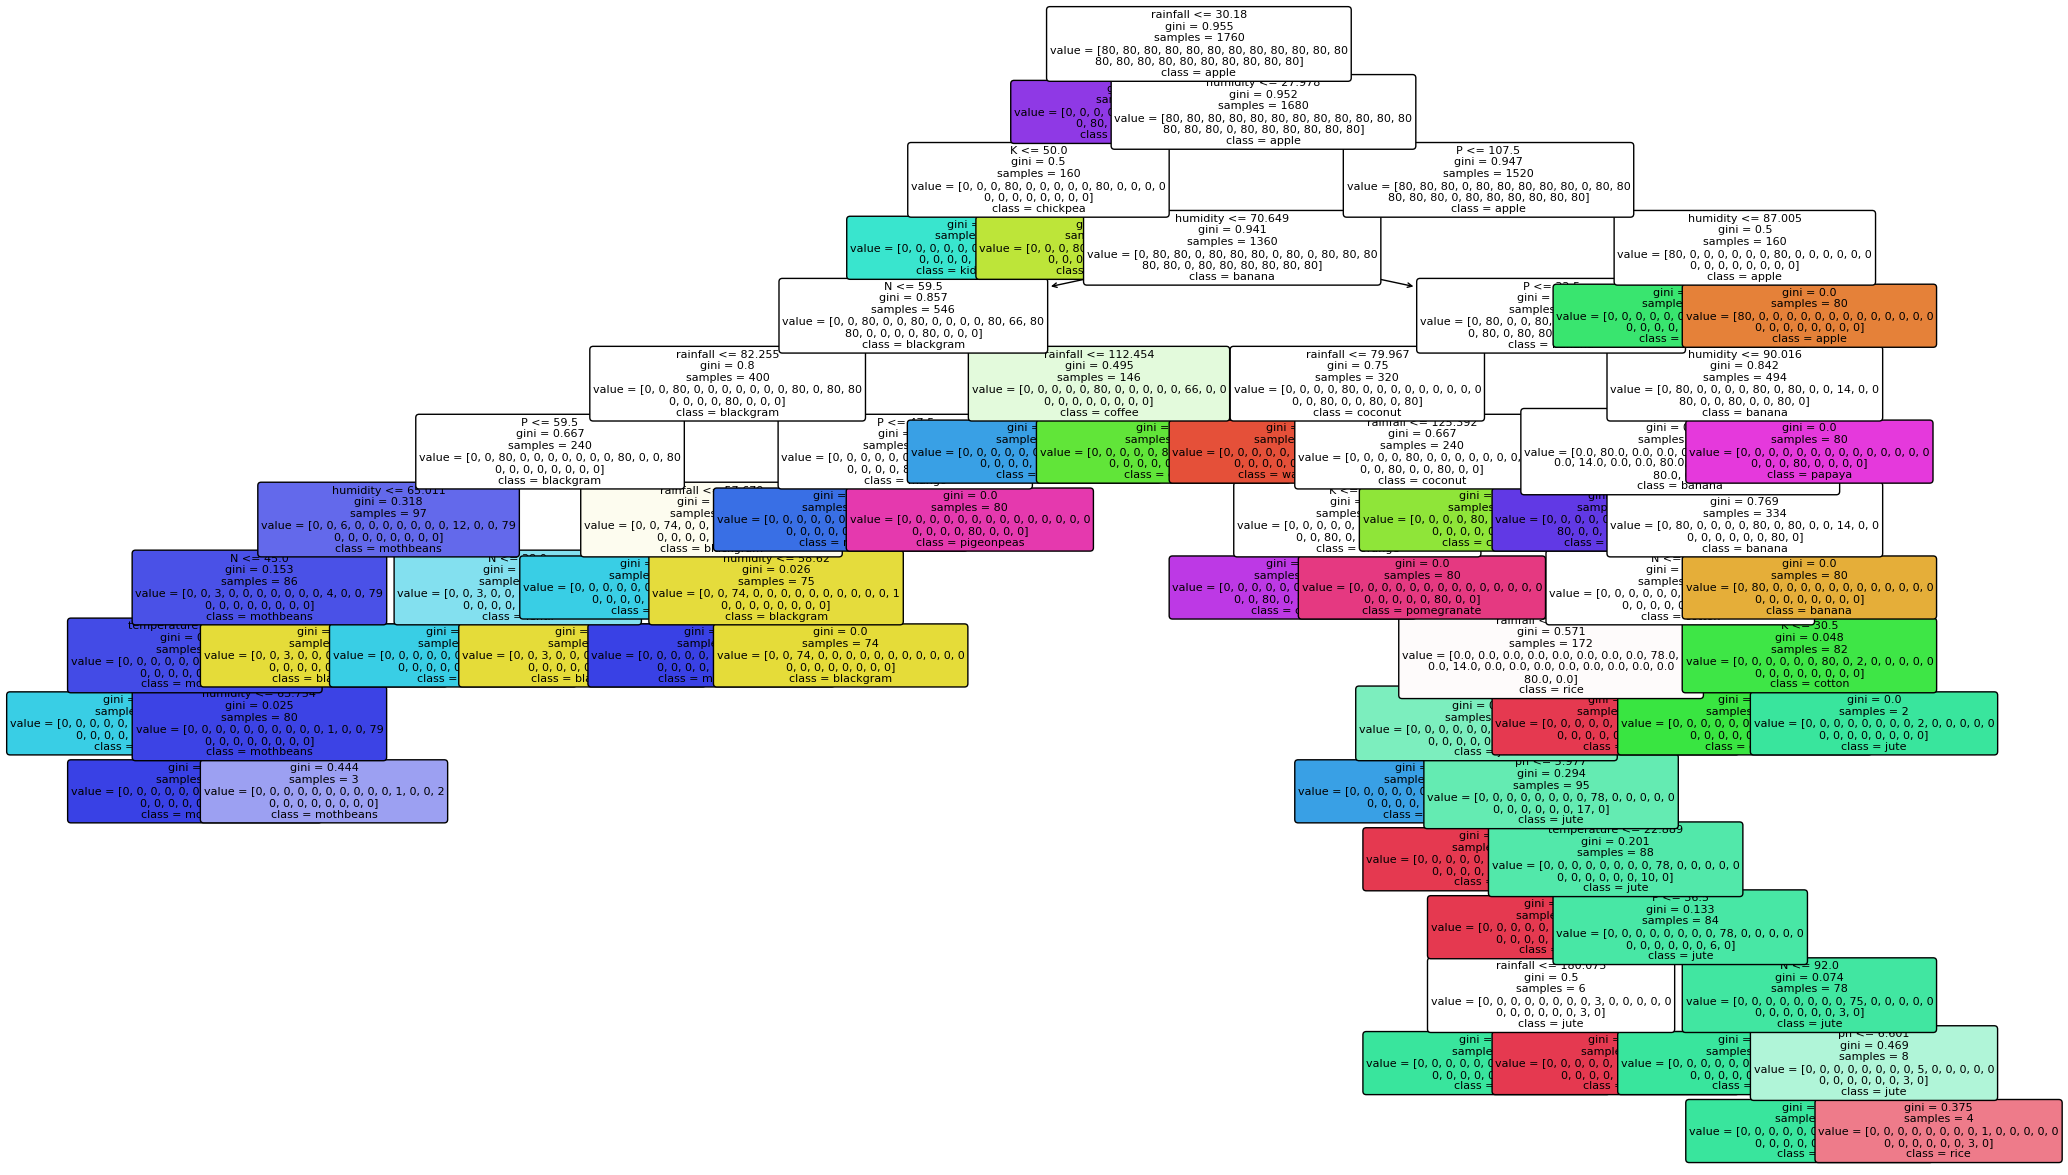

In [167]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,15))

plot_tree( best_dt, feature_names = x.columns, class_names = le.classes_ , filled =  True, rounded = True, fontsize = 8 )

plt.show()

In [168]:
# Predict on New Data

sample = [[90, 42, 43, 20.5, 82, 6.5, 210]]

prediction = best_dt.predict(sample)

C:\Users\mohan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [170]:
print("Encoded Prediction:", prediction)

print( "Recommended Crop:", le.inverse_transform(prediction))

Encoded Prediction: [20]
Recommended Crop: ['rice']


# Conclusion

In this project, a **Decision Tree Classifier** was developed to recommend the most suitable crop based on soil nutrients (**Nitrogen, Phosphorus, and Potassium**) and environmental factors such as **temperature, humidity, pH, and rainfall**. A complete machine learning workflow was followed, including exploratory data analysis, outlier investigation, feature engineering, model training, hyperparameter tuning using **GridSearchCV**, and feature importance analysis.

The final model achieved an accuracy of approximately **97%**, demonstrating its ability to accurately recommend crops for different soil and climatic conditions. Feature importance analysis showed that **rainfall, phosphorus, and humidity** were the most influential factors in the model's predictions. 

This crop recommendation system can help farmers make **data-driven decisions** instead of relying solely on traditional practices. By recommending crops that are better suited to the existing soil and weather conditions, it can:

* Improve crop productivity and yield.
* Reduce the risk of selecting unsuitable crops.
* Promote efficient use of fertilizers and water resources.
* Support sustainable farming practices.
* Help farmers increase profitability by choosing crops with a higher likelihood of successful growth.

Overall, this project demonstrates how machine learning can be applied to agriculture to support informed decision-making and contribute to more efficient and sustainable farming.
